In [4]:
import os
from google.colab import drive

# 1. Montar Google Drive
drive.mount('/content/drive', force_remount=True)

# 2. Buscar el zip del dataset en rutas candidatas
extract_path = '/content/dataset'
os.makedirs(extract_path, exist_ok=True)

rutas_candidatas = [
    '/content/drive/MyDrive/Carrera/Inteligencia Artificial/dataset_final.zip',
    '/content/drive/MyDrive/dataset_final.zip',
    '/content/drive/MyDrive/Carrera/dataset_final.zip',
]

zip_path = next((ruta for ruta in rutas_candidatas if os.path.exists(ruta)), None)

# 3. Si no aparece en rutas fijas, buscarlo en todo Drive
if zip_path is None:
    for raiz, _, archivos in os.walk('/content/drive/MyDrive'):
        if 'dataset_final.zip' in archivos:
            zip_path = os.path.join(raiz, 'dataset_final.zip')
            break

if zip_path is None:
    print('❌ No se encontró dataset_final.zip en tu Drive.')
    print('Tip: en Drive, crea un acceso directo de la carpeta compartida dentro de Mi unidad.')
    print('Luego vuelve a ejecutar esta celda.')
else:
    print(f'✅ ZIP encontrado en: {zip_path}')
    !unzip -q -o "{zip_path}" -d "{extract_path}"
    print(f'✅ Dataset descomprimido en: {extract_path}')

Mounted at /content/drive
✅ ZIP encontrado en: /content/drive/MyDrive/Carrera/Inteligencia Artificial/dataset_final.zip
✅ Dataset descomprimido en: /content/dataset


In [5]:
!ls /content/dataset/dataset_final/train/objeto_a | head -n 5

001_c1.jpg
001_c2.jpg
001_c3.jpg
001_c4.jpg
002_c1.jpg


Found 1120 files belonging to 2 classes.
Found 148 files belonging to 2 classes.
Found 156 files belonging to 2 classes.
Class names: ['fondo_vacio', 'objeto_a']

🚀 Iniciando entrenamiento...
Epoch 1/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.5348 - loss: 0.7364 - val_accuracy: 0.6959 - val_loss: 0.5467
Epoch 2/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.6607 - loss: 0.5905 - val_accuracy: 0.7770 - val_loss: 0.4740
Epoch 3/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.7723 - loss: 0.4674 - val_accuracy: 0.8311 - val_loss: 0.3982
Epoch 4/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.8571 - loss: 0.3871 - val_accuracy: 0.8378 - val_loss: 0.3508
Epoch 5/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.8875 - loss: 0.3448 - val_accuracy: 0.8784 - val_loss: 0.3136
Epoch 6/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.9062 - loss: 0.3001 - val_accuracy: 0.8851 - val_loss: 0.2770
Epoch 7/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - 

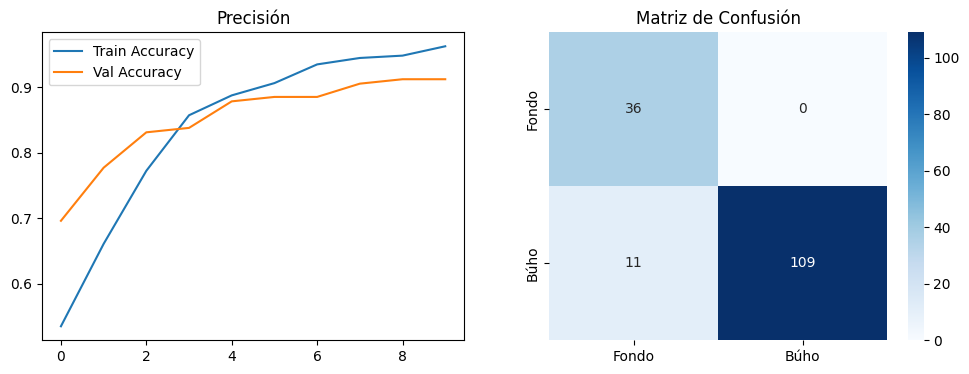

✅ Modelo guardado en: /content/drive/MyDrive/Carrera/Inteligencia Artificial/modelo_buho_v1.h5


In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import os

# 1. Configuración de rutas (basado en el !ls exitoso)
base_path = '/content/dataset/dataset_final'
train_dir = os.path.join(base_path, 'train')
val_dir = os.path.join(base_path, 'val')
test_dir = os.path.join(base_path, 'test')

# 2. Carga de datos optimizada
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(train_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary')
val_ds = tf.keras.utils.image_dataset_from_directory(val_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary')
test_ds = tf.keras.utils.image_dataset_from_directory(test_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary', shuffle=False)

print('Class names:', train_ds.class_names)

# 2b. Aplicar preprocess_input a los datasets (normaización nativa de MobileNetV2: [-1, 1])
train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))
test_ds = test_ds.map(lambda x, y: (preprocess_input(x), y))

# 3. Arquitectura MobileNetV2 (Transfer Learning)
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # Congelamos el conocimiento previo

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2), # Para evitar que memorice (overfitting)
    layers.Dense(1, activation='sigmoid') # Salida binaria: 0 o 1
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# 4. Entrenamiento
print("\n🚀 Iniciando entrenamiento...")
history = model.fit(train_ds, validation_data=val_ds, epochs=10)

# 5. Visualización de Resultados
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Precisión')
plt.legend()

# 6. Matriz de Confusión
print("\n📊 Generando Matriz de Confusión...")
y_true = np.concatenate([y for x, y in test_ds], axis=0)
preds = model.predict(test_ds)
y_pred = (preds > 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)
plt.subplot(1, 2, 2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fondo', 'Búho'], yticklabels=['Fondo', 'Búho'])
plt.title('Matriz de Confusión')
plt.show()

# 7. Guardar el modelo en Drive
model_save_path = '/content/drive/MyDrive/Carrera/Inteligencia Artificial/modelo_buho_v1.h5'
model.save(model_save_path)
print(f"✅ Modelo guardado en: {model_save_path}")